# Attention & Transformers

**Part 1** implements scaled dot-product self-attention from scratch in NumPy on a tiny toy sequence, visualizing the attention-weight matrix as a heatmap to build intuition (per `notes.md`).

**Part 2** builds a small Keras Transformer-encoder-based text classifier (`MultiHeadAttention` + `LayerNormalization` + Dense layers) on `tf.keras.datasets.imdb`, following the standard Keras "Text classification with Transformer" pattern.

## Part 1 — Self-attention from scratch in NumPy

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    weights = softmax(scores, axis=-1)
    output = weights @ V
    return output, weights

### A tiny toy sequence

We represent 6 'tokens' as random embedding vectors, then project them into Query, Key, Value spaces with random (but fixed-seed) weight matrices — exactly the $Q=XW^Q$, $K=XW^K$, $V=XW^V$ projections from `notes.md`.

In [2]:
tokens = ['the', 'cat', 'sat', 'on', 'the', 'mat']
seq_len = len(tokens)
d_model = 8
d_k = 4

X = np.random.randn(seq_len, d_model)

W_Q = np.random.randn(d_model, d_k) * 0.5
W_K = np.random.randn(d_model, d_k) * 0.5
W_V = np.random.randn(d_model, d_k) * 0.5

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

output, attn_weights = scaled_dot_product_attention(Q, K, V)
print('Output shape:', output.shape)
print('Attention weights shape:', attn_weights.shape)
print('Each row sums to 1:', np.allclose(attn_weights.sum(axis=1), 1.0))

Output shape: (6, 4)
Attention weights shape: (6, 6)
Each row sums to 1: True


### Visualize the attention-weight matrix

Row $i$ shows how much token $i$ (as a query) attends to every other token (as a key) — this is exactly the $\text{softmax}(QK^T/\sqrt{d_k})$ matrix from `notes.md`.

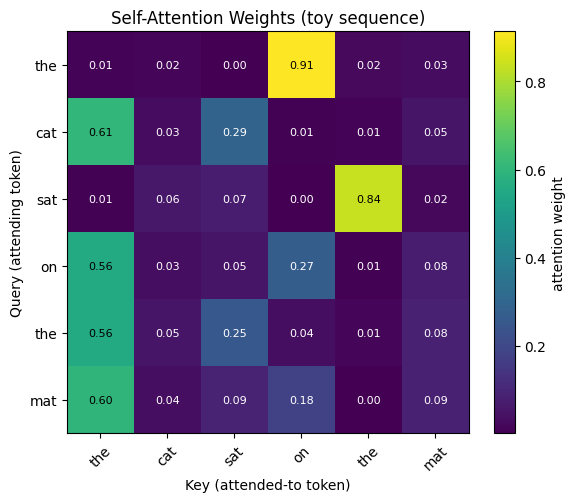

In [3]:
plt.figure(figsize=(6, 5))
plt.imshow(attn_weights, cmap='viridis')
plt.colorbar(label='attention weight')
plt.xticks(range(seq_len), tokens, rotation=45)
plt.yticks(range(seq_len), tokens)
plt.xlabel('Key (attended-to token)')
plt.ylabel('Query (attending token)')
plt.title('Self-Attention Weights (toy sequence)')
for i in range(seq_len):
    for j in range(seq_len):
        plt.text(j, i, f'{attn_weights[i, j]:.2f}', ha='center', va='center',
                  color='white' if attn_weights[i, j] < 0.5 else 'black', fontsize=8)
plt.tight_layout()
plt.show()

## Part 2 — A Transformer-encoder text classifier on IMDB

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences

tf.random.set_seed(42)

VOCAB_SIZE = 10000
MAX_LEN = 200
EMBED_DIM = 32
NUM_HEADS = 2
FF_DIM = 32

(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)
X_train_full = pad_sequences(X_train_full, maxlen=MAX_LEN)
X_test = pad_sequences(X_test, maxlen=MAX_LEN)

val_split = 5000
X_train, X_val = X_train_full[:-val_split], X_train_full[-val_split:]
y_train, y_val = y_train_full[:-val_split], y_train_full[-val_split:]

print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

I0000 00:00:1787472408.858272   30941 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787472408.858645   30941 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787472408.895568   30941 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787472409.687386   30941 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787472409.687632   30941 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


/home/yashwanth-aravind/ml-course/python-bootcamp/.venv/lib/python3.13/site-packages/keras/src/datasets/npz_utils.py:68: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return RestrictedUnpickler(fp).load()


Train: (20000, 200) Val: (5000, 200) Test: (25000, 200)


### Transformer encoder block

A custom Keras layer implementing `MultiHeadAttention` + residual + `LayerNormalization`, followed by a position-wise feed-forward network + another residual + `LayerNormalization`, exactly as described in `notes.md`.

In [5]:
class TransformerEncoderBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

### Token + positional embedding

Since self-attention has no inherent notion of order (per `notes.md`), we add a learned positional embedding to the token embedding, following the standard Keras "Text classification with Transformer" pattern.

In [6]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

### Assemble the classifier

In [7]:
inputs = layers.Input(shape=(MAX_LEN,))
x = TokenAndPositionEmbedding(MAX_LEN, VOCAB_SIZE, EMBED_DIM)(inputs)
x = TransformerEncoderBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(20, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

E0000 00:00:1787472413.102794   30941 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787472413.103069   31012 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1787472413.127574   30941 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 200, 32)        │       326,400 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_block       │ (None, 200, 32)        │         6,464 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,545 (1.27 MB)

 Trainable params: 333,545 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=6, batch_size=128,
    callbacks=[early_stop], verbose=2)

Epoch 1/6


157/157 - 9s - 55ms/step - accuracy: 0.6583 - loss: 0.5991 - val_accuracy: 0.8096 - val_loss: 0.4430


Epoch 2/6


157/157 - 7s - 44ms/step - accuracy: 0.8794 - loss: 0.3090 - val_accuracy: 0.8778 - val_loss: 0.3064


Epoch 3/6


157/157 - 7s - 44ms/step - accuracy: 0.9187 - loss: 0.2178 - val_accuracy: 0.8762 - val_loss: 0.3159


Epoch 4/6


157/157 - 7s - 46ms/step - accuracy: 0.9367 - loss: 0.1748 - val_accuracy: 0.8460 - val_loss: 0.4515


### Training curves

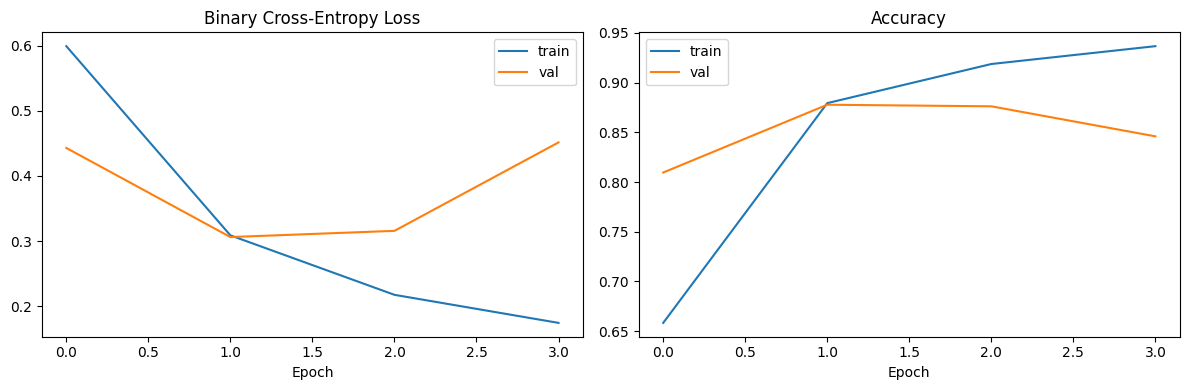

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['loss'], label='train')
ax[0].plot(history.history['val_loss'], label='val')
ax[0].set_title('Binary Cross-Entropy Loss'); ax[0].set_xlabel('Epoch'); ax[0].legend()

ax[1].plot(history.history['accuracy'], label='train')
ax[1].plot(history.history['val_accuracy'], label='val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].legend()
plt.tight_layout()
plt.show()

### Evaluate on the test set

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss:     {test_loss:.4f}')

Test accuracy: 0.8748
Test loss:     0.3092


## Summary

The from-scratch NumPy attention matrix in Part 1 shows exactly what the `MultiHeadAttention` layer computes internally in Part 2: for every token, a weighted blend of the whole sequence's value vectors, with weights driven by query-key similarity. Combined with a learned positional embedding and layer normalization, a single Transformer encoder block is enough to reach competitive sentiment-classification accuracy on IMDB — without any recurrence.